El Harraj Imane

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
df = pd.read_csv("../data/data.csv")
df.head()

,SNo,X_1,X_2,y
0,0,-0.869144,0.389310,0.0
1,1,-0.993467,-0.610591,0.0
2,2,-0.834064,0.239236,0.0
3,3,-0.136471,0.632003,1.0
4,4,0.403887,0.310784,1.0


In [14]:
X_train = df[['X_1','X_2']].values
y_train = df['y '].values

m, n = X_train.shape

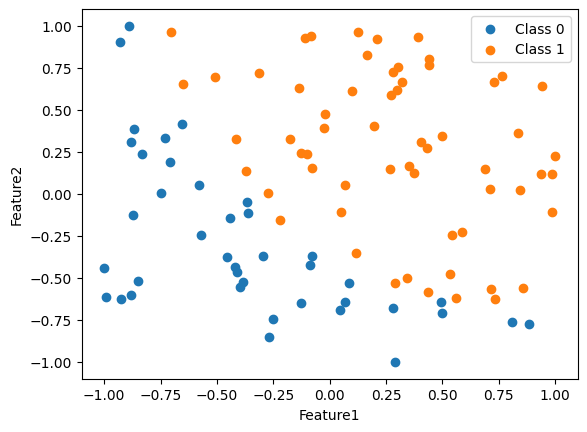

In [15]:
plt.scatter(X_train[y_train == 0, 0],X_train[y_train == 0, 1], color='tab:blue',label='Class 0')
plt.scatter(X_train[y_train == 1, 0],X_train[y_train == 1, 1], color='tab:orange',label='Class 1')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend()

In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [17]:
def cost_function(X, y, w, b):
    m = X.shape[0]
    z = np.dot(X, w) + b
    g = sigmoid(z)

    cost = (-1/m) * np.sum(y * np.log(g) + (1 - y) * np.log(1 - g))
    return cost

In [18]:
def gradient_function(X, y, w, b):
    m = X.shape[0]
    z = np.dot(X, w) + b
    g = sigmoid(z)
    
    err = g - y
    
    dj_dw = (1/m) * np.dot(X.T, err)
    dj_db = (1/m) * np.sum(err)
    
    return dj_db, dj_dw

In [19]:
def gradient_descent(X, y, alpha, iterations):
    w = np.zeros(n)
    b = 0

    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)

        w = w - alpha * grad_w
        b = b - alpha * grad_b

        if i % 200 == 0:
            print(f"iteration {i}: cost {cost_function(X, y, w, b)}")
        
    return w, b

In [20]:
def predict(X, w, b):
    preds = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        preds[i] = 1 if g>= 0.5 else 0

    return preds

In [21]:
learning_rate = 0.1
iterations = 2000

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, iterations)

predictions = predict(X_train, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"training accurancy: {accuracy:.2f}%")

iteration 0: cost 0.6877106378080856
iteration 200: cost 0.3546028249806682
iteration 400: cost 0.2916525585769229
iteration 600: cost 0.2644803695840938
iteration 800: cost 0.24913563103200873
iteration 1000: cost 0.23924181906139236
iteration 1200: cost 0.23234025014985246
iteration 1400: cost 0.227268696399857
iteration 1600: cost 0.22340157393711707
iteration 1800: cost 0.22037033787030894
training accurancy: 89.00%


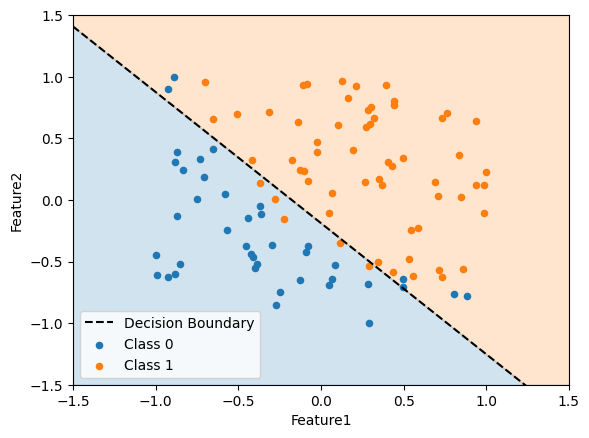

In [22]:
m = -final_w[0] / final_w[1]
c = -final_b / final_w[1]

xmin, xmax = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
ymin, ymax = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xd = np.array([xmin, xmax])
yd = m * xd + c

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:blue', alpha=0.2)
plt.fill_between(xd, yd, ymax, color='tab:orange', alpha=0.2)

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:blue', label='Class 0', s=20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='tab:orange', label='Class 1', s=20)
plt.legend()
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()